# Introduction to Python


Kai Zhang, The University of Texas at Tyler


To learn Python, find some online tutorials or books, and practice with it, starting with running Python interactively, e.g. on Jupyter notebook or Colab.

No need to master all the aspects of Python programming at once. 

Ask AI to help you draft and improve codes. But as a beginner, reserve the understanding and learning to yourself.


__References__:


* Online practice

Beginner tutorial https://www.w3schools.com/python/

Coding practice https://www.geeksforgeeks.org/python-exercises-practice-questions-and-solutions/

* Books

Python Scripting for Computational Molecular Science https://education.molssi.org/python_scripting_cms/

A Practical Introduction to Python Programming https://www.brianheinold.net/python/python_book.html

The Quick Python Book https://www.manning.com/books/the-quick-python-book-fourth-edition

Data structure and algorithm https://runestone.academy/ns/books/published/pythonds/index.html

Computational Physics, 2nd edition, by Mark Newman https://websites.umich.edu/~mejn/cp2/programs.html

Introduction to Computer Science and Programming in Python https://ocw.mit.edu/courses/6-0001-introduction-to-computer-science-and-programming-in-python-fall-2016/pages/lecture-slides-code/



## 1. Python packages (libraries)

Check notebook `0_intro_to_Jupyter.ipybo` for virtual environment setup and `pip install` Python packages.

Some commonly used Python packages for data science, machine learning and computational chemistry

```python
import numpy as np	            # Numerical arrays, linear algebra, mathematical operations
import scipy	                # Scientific computing, optimization, integration, statistics
import pandas as pd 	        # Data manipulation and tabular data
import matplotlib.pyplot as plt	# Plotting and visualization
import seaborn as sns	        # Statistical visualization
import sympy as sp              # SymPy Symbolic mathematics

import sklearn                  # scikit-learn, Classical machine learning
import torch                    # PyTorch Deep learning and neural networks (most popular)
import tensorflow as tf         # Deep learning
import jax                      # JAX High-performance numerical computing and ML
import xgboost                  # XGBoost Gradient-boosted decision trees

from rdkit import Chem          # RDKit Cheminformatics and molecular structures
import ase                      # ASE Atomic Simulation Environment; molecular/atomistic simulations
import MDAnalysis as mda        # MDAnalysis Analysis of molecular dynamics trajectories
import mdtraj                   # MDTraj Molecular dynamics trajectory analysis
import openmm                   # OpenMM Molecular dynamics simulations
import pyscf                    # PySCF Quantum chemistry
```

## 2. Numpy for arrays and linear algebra

__Array Slicing__

![Array slicing](figures/array_slicing.JPG)

## 3. Matplotlib for scientific plotting

__References__

https://colab.research.google.com/drive/1uUfXQFPSCCPd9v_xQC1EgaYE39ekxnbg#scrollTo=AHRyXFswb354

## 4. Object-oriented programming (OOP)

(may be saved for later study )

Below is a sample oop code for a small neural network using numpy only.

Mathematically, 

\begin{align}
\mathbf{h} = \tanh\left(\mathbf{X}\mathbf{W}_1 + \mathbf{b}_1\right)
\end{align}

\begin{align}
\hat{\mathbf{y}} = \mathbf{h}\mathbf{W}_2 + \mathbf{b}_2
\end{align}
with a mean-squared error (MSE) loss function
\begin{align}
L = \frac{1}{N}\sum_{i=1}^{N}\left(\hat{y}_i-y_i\right)^2
\end{align}

In [1]:
import numpy as np

class NeuralNetwork:
    def __init__(self, input_size, hidden_size, output_size):
        # Initialize weights and biases
        self.W1 = np.random.randn(input_size, hidden_size) * 0.1
        self.b1 = np.zeros((1, hidden_size))

        self.W2 = np.random.randn(hidden_size, output_size) * 0.1
        self.b2 = np.zeros((1, output_size))

    def tanh(self, x):
        return np.tanh(x)

    def tanh_derivative(self, x):
        return 1 - np.tanh(x) ** 2

    def forward(self, X):
        # Hidden layer
        self.z1 = X @ self.W1 + self.b1
        self.a1 = self.tanh(self.z1)

        # Output layer
        self.z2 = self.a1 @ self.W2 + self.b2

        return self.z2

    def train(self, X, y, learning_rate=0.01, epochs=5000):

        losses = []

        for epoch in range(epochs):

            # Forward pass
            y_pred = self.forward(X)

            # Loss
            loss = np.mean((y_pred - y) ** 2)
            losses.append(loss)

            # Backpropagation
            dz2 = 2 * (y_pred - y) / len(X)

            dW2 = self.a1.T @ dz2
            db2 = np.sum(dz2, axis=0, keepdims=True)

            da1 = dz2 @ self.W2.T
            dz1 = da1 * self.tanh_derivative(self.z1)

            dW1 = X.T @ dz1
            db1 = np.sum(dz1, axis=0, keepdims=True)

            # Update parameters
            self.W2 -= learning_rate * dW2
            self.b2 -= learning_rate * db2

            self.W1 -= learning_rate * dW1
            self.b1 -= learning_rate * db1
            
            if epoch % 100 == 0: 
                print(f"Epoch {epoch}, Loss = {loss:.6f}")
        
        return losses
# --------------------------------
# Example: fit y = sin(x)
# --------------------------------

X = np.linspace(-np.pi, np.pi, 100).reshape(-1, 1)
y = np.sin(X)

# 1 input → 10 hidden neurons → 1 output
model = NeuralNetwork(
    input_size=1,
    hidden_size=10,
    output_size=1
)

losses = model.train(
    X,
    y,
    learning_rate=0.01,
    epochs=5000
)

# Prediction
y_pred = model.forward(X)

Epoch 0, Loss = 0.506990
Epoch 100, Loss = 0.184160
Epoch 200, Loss = 0.175390
Epoch 300, Loss = 0.167801
Epoch 400, Loss = 0.158140
Epoch 500, Loss = 0.146672
Epoch 600, Loss = 0.134005
Epoch 700, Loss = 0.120893
Epoch 800, Loss = 0.107997
Epoch 900, Loss = 0.095767
Epoch 1000, Loss = 0.084459
Epoch 1100, Loss = 0.074200
Epoch 1200, Loss = 0.065054
Epoch 1300, Loss = 0.057044
Epoch 1400, Loss = 0.050165
Epoch 1500, Loss = 0.044372
Epoch 1600, Loss = 0.039585
Epoch 1700, Loss = 0.035694
Epoch 1800, Loss = 0.032570
Epoch 1900, Loss = 0.030086
Epoch 2000, Loss = 0.028120
Epoch 2100, Loss = 0.026563
Epoch 2200, Loss = 0.025323
Epoch 2300, Loss = 0.024327
Epoch 2400, Loss = 0.023515
Epoch 2500, Loss = 0.022841
Epoch 2600, Loss = 0.022269
Epoch 2700, Loss = 0.021773
Epoch 2800, Loss = 0.021333
Epoch 2900, Loss = 0.020936
Epoch 3000, Loss = 0.020570
Epoch 3100, Loss = 0.020228
Epoch 3200, Loss = 0.019905
Epoch 3300, Loss = 0.019597
Epoch 3400, Loss = 0.019301
Epoch 3500, Loss = 0.019015
Epoc

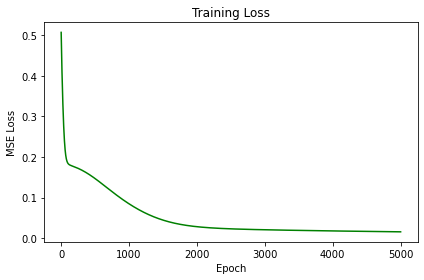

In [2]:
import matplotlib.pyplot as plt

# --------------------------------
# Plot training loss
# --------------------------------

plt.figure(figsize=(6, 4))

plt.plot(losses, 'g-')

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Loss")

plt.tight_layout()
plt.show()


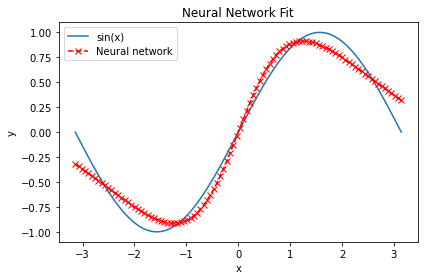

In [3]:
# --------------------------------
# Compare sin(x) with prediction
# --------------------------------

plt.figure(figsize=(6, 4))

plt.plot(X, y, label="sin(x)")
plt.plot(X, y_pred, "rx--", label="Neural network")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Neural Network Fit")

plt.legend()
plt.tight_layout()
plt.show()

## 5. Run Python script in command line

###  The End